---
title: "SSH 1: Models and Bands"
subtitle: "From Alternating Bonds to a Bloch Hamiltonian"
artifact_status: "Exploratory beginner notebook; not canonical or supported"
---

# SSH 1: Models and Bands

The Su--Schrieffer--Heeger (SSH) model is a one-dimensional tight-binding model with two sites, $A$ and $B$, in each unit cell. A particle can hop along alternating bonds with real amplitudes $t_1$ and $t_2$.

This notebook assumes a spinless, non-interacting, single-particle model with zero onsite energies. It introduces the chain visually, constructs finite Hamiltonian matrices, derives the $2\times2$ Bloch Hamiltonian, and compares trivial, critical, and topological parameter cases. These labels are defined under the cell convention shown below.

## Learning objectives

After this notebook, you should be able to identify the two alternating hoppings, assemble open and periodic real-space Hamiltonians, derive the Bloch bands, and locate the gap closing at $t_1=t_2$.

## Prerequisites and numerical-check boundary

The sequence assumes basic Python, NumPy, and Matplotlib; finite matrices, eigenvalues, and eigenvectors; complex phases; and an introductory idea of Bloch/Fourier representations. Pauli matrices are introduced when needed in notebook 2. No prior knowledge of the SSH model or topological bands is assumed.

Deterministic comparisons use a task-local absolute tolerance of $10^{-10}$ with relative tolerance set to zero for the selected float64/complex128 finite examples. This is not a universal numerical tolerance.


## 1. Alternating bonds and the unit cell

Our unit cell contains $A_R$ and $B_R$. The intracell hopping $t_1$ joins $A_R$ to $B_R$; the intercell hopping $t_2$ joins $B_R$ to $A_{R+1}$:

$$
\hat H=\sum_R\left(t_1|R,A\rangle\langle R,B|+t_2|R+1,A\rangle\langle R,B|+\mathrm{h.c.}\right).
$$

The overall sign of the hopping can be changed by a basis convention in this bipartite example. We use positive $t_1,t_2$ throughout.


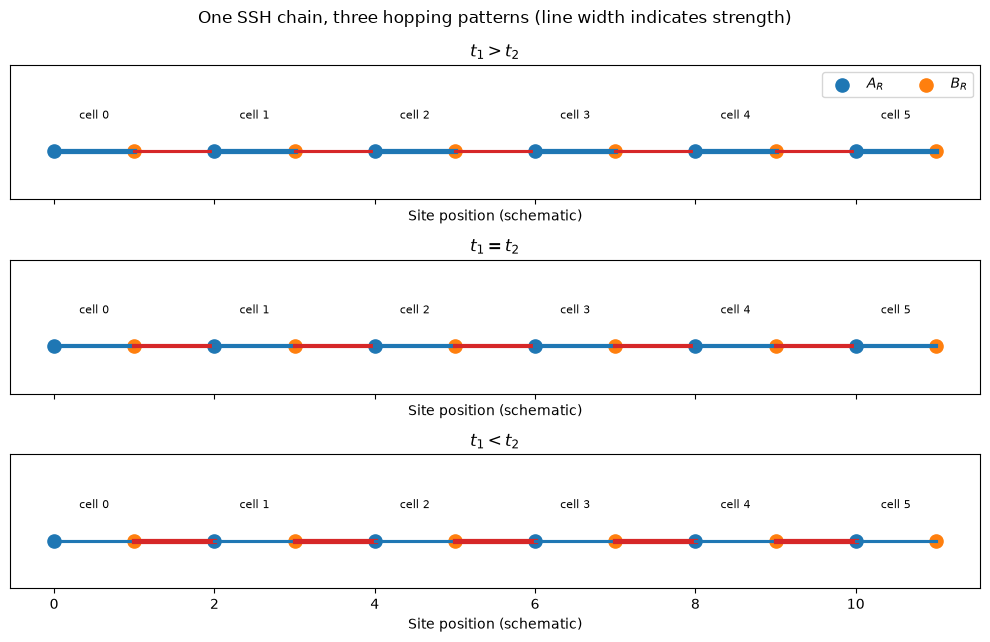

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

ATOL = 1.0e-10


def draw_chain(ax, t1, t2, cells=6, title=""):
    x_a = 2 * np.arange(cells)
    x_b = x_a + 1
    ax.scatter(x_a, np.zeros(cells), s=90, color="tab:blue", label="$A_R$")
    ax.scatter(x_b, np.zeros(cells), s=90, color="tab:orange", label="$B_R$")
    for r in range(cells):
        ax.plot([x_a[r], x_b[r]], [0, 0], linewidth=1.5 + 3.0 * t1 / (t1 + t2), color="tab:blue")
        if r < cells - 1:
            ax.plot([x_b[r], x_a[r + 1]], [0, 0], linewidth=1.5 + 3.0 * t2 / (t1 + t2), color="tab:red")
    for r in range(cells):
        ax.text(x_a[r] + 0.5, 0.17, f"cell {r}", ha="center", fontsize=8)
    ax.set_title(title)
    ax.set_yticks([])
    ax.set_xlabel("Site position (schematic)")
    ax.set_ylim(-0.25, 0.45)

fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
for ax, (t1, t2, label) in zip(
    axes,
    [(1.5, 0.5, "$t_1>t_2$"), (1.0, 1.0, "$t_1=t_2$"), (0.5, 1.5, "$t_1<t_2$")],
):
    draw_chain(ax, t1, t2, title=label)
axes[0].legend(loc="upper right", ncol=2)
fig.suptitle("One SSH chain, three hopping patterns (line width indicates strength)")
fig.tight_layout()
plt.show()


### Interpretation

The blue intracell and red intercell links alternate along the chain. When $t_1>t_2$, the strongest bonds lie inside the chosen cells. When $t_1<t_2$, the strongest bonds connect neighboring cells. At $t_1=t_2$, the dimerization disappears and the chosen two-site cell is no longer distinguished by bond strength.


## 2. Finite real-space matrices

For $N$ cells, the basis ordering is $(A_0,B_0,A_1,B_1,\ldots)$. An open chain omits the final $B_{N-1}$--$A_0$ link. A periodic chain includes it.


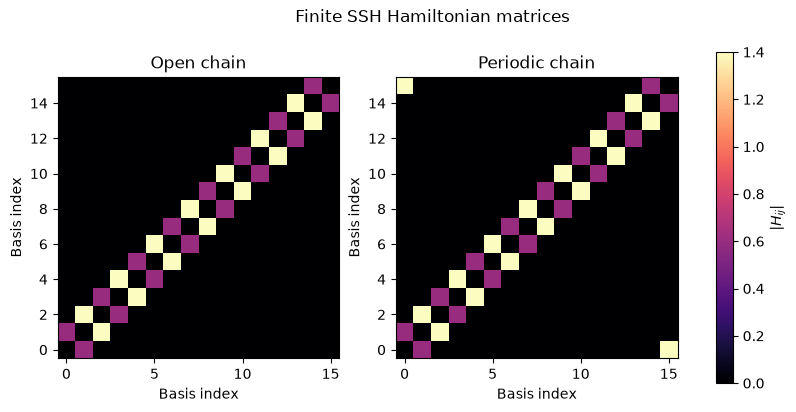

In [2]:
def ssh_real_hamiltonian(cells, t1, t2, periodic=False):
    H = np.zeros((2 * cells, 2 * cells), dtype=float)
    for r in range(cells):
        a_r, b_r = 2 * r, 2 * r + 1
        H[a_r, b_r] = H[b_r, a_r] = t1
        if r < cells - 1:
            a_next = 2 * (r + 1)
            H[b_r, a_next] = H[a_next, b_r] = t2
        elif periodic:
            H[b_r, 0] = H[0, b_r] = t2
    return H

cells = 8
t1, t2 = 0.6, 1.4
H_open = ssh_real_hamiltonian(cells, t1, t2, periodic=False)
H_periodic = ssh_real_hamiltonian(cells, t1, t2, periodic=True)
assert_allclose(H_open, H_open.T, atol=ATOL, rtol=0.0)
assert_allclose(H_periodic, H_periodic.T, atol=ATOL, rtol=0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, H, title in zip(axes, [H_open, H_periodic], ["Open chain", "Periodic chain"]):
    image = ax.imshow(np.abs(H), origin="lower", cmap="magma", vmin=0, vmax=t2)
    ax.set_title(title)
    ax.set_xlabel("Basis index")
    ax.set_ylabel("Basis index")
fig.colorbar(image, ax=axes, label="$|H_{ij}|$")
fig.suptitle("Finite SSH Hamiltonian matrices")
plt.show()


### Interpretation

Both matrices contain alternating nearest-neighbor entries and are explicitly checked to be Hermitian. The periodic matrix has two additional corner entries that connect the final and first cells. Boundary conditions therefore change a small part of the finite matrix while leaving its repeated bulk pattern intact.


## 3. Bloch Hamiltonian

For a periodic chain, define Bloch basis states from cell translations. With the convention used here,

$$
H(k)=\begin{pmatrix}0&q(k)\\q(k)^*&0\end{pmatrix},
\qquad q(k)=t_1+t_2e^{-ik}.
$$

The two energies are

$$
E_\pm(k)=\pm|q(k)|
=\pm\sqrt{t_1^2+t_2^2+2t_1t_2\cos k}.
$$


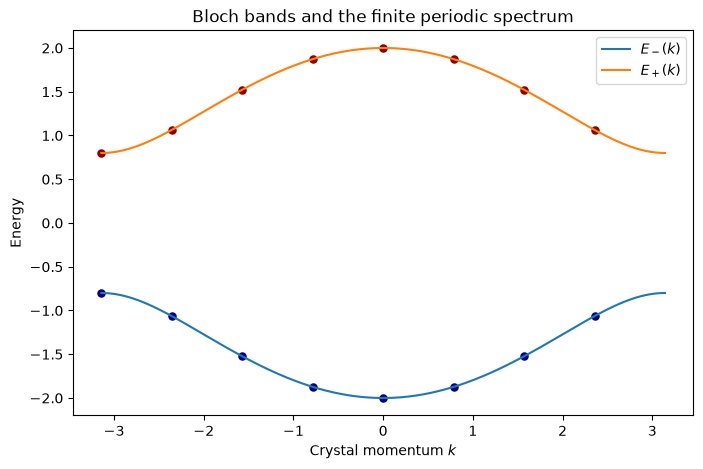

In [3]:
def ssh_bloch_hamiltonian(k, t1, t2):
    q = t1 + t2 * np.exp(-1j * k)
    return np.array([[0.0, q], [np.conjugate(q), 0.0]], dtype=complex)

k_values = 2.0 * np.pi * np.arange(cells) / cells
bloch_energies = np.array([np.linalg.eigvalsh(ssh_bloch_hamiltonian(k, t1, t2)) for k in k_values])
periodic_energies = np.linalg.eigvalsh(H_periodic)
assert_allclose(np.sort(bloch_energies.ravel()), periodic_energies, atol=ATOL, rtol=0.0)

k_dense = np.linspace(-np.pi, np.pi, 501)
analytic = np.sqrt(t1**2 + t2**2 + 2 * t1 * t2 * np.cos(k_dense))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_dense, -analytic, color="tab:blue", label="$E_-(k)$")
ax.plot(k_dense, analytic, color="tab:orange", label="$E_+(k)$")
# Display the finite periodic eigenvalues at equivalent momenta in [-pi, pi).
k_plot = (k_values + np.pi) % (2 * np.pi) - np.pi
ax.scatter(k_plot, bloch_energies[:, 0], color="navy", s=26)
ax.scatter(k_plot, bloch_energies[:, 1], color="darkred", s=26)
ax.set_xlabel("Crystal momentum $k$")
ax.set_ylabel("Energy")
ax.set_title("Bloch bands and the finite periodic spectrum")
ax.legend()
plt.show()


### Interpretation

The continuous curves are the analytic bands, while the points are the momenta available to the eight-cell periodic chain. The executable comparison checks that the complete periodic real-space spectrum equals the collection of Bloch-fiber eigenvalues. This verifies the finite representations under the stated convention; it is not material validation.


## 4. Three regimes

The band separation is smallest at $k=\pi$ and equals

$$
E_+(\pi)-E_-(\pi)=2|t_1-t_2|.
$$

The gap is open when the two hoppings differ and closes when they are equal.


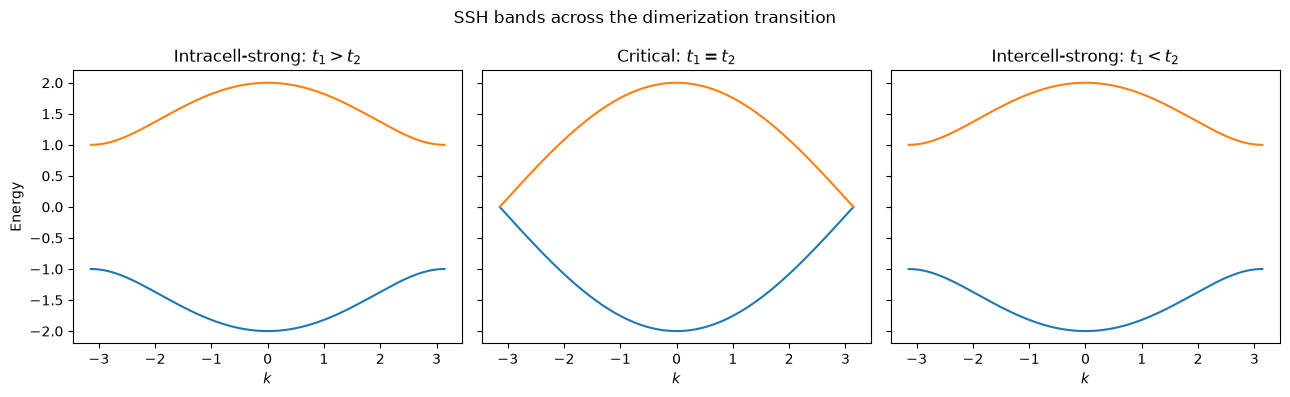

In [4]:
parameter_cases = [
    (1.5, 0.5, "Intracell-strong: $t_1>t_2$"),
    (1.0, 1.0, "Critical: $t_1=t_2$"),
    (0.5, 1.5, "Intercell-strong: $t_1<t_2$"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (v1, v2, title) in zip(axes, parameter_cases):
    e = np.sqrt(v1**2 + v2**2 + 2 * v1 * v2 * np.cos(k_dense))
    ax.plot(k_dense, -e, color="tab:blue")
    ax.plot(k_dense, e, color="tab:orange")
    expected_gap = 2.0 * abs(v1 - v2)
    observed_gap = 2.0 * np.min(e)
    assert_allclose(observed_gap, expected_gap, atol=ATOL, rtol=0.0)
    ax.set_title(title)
    ax.set_xlabel("$k$")
axes[0].set_ylabel("Energy")
fig.suptitle("SSH bands across the dimerization transition")
fig.tight_layout()
plt.show()


### Interpretation

Both dimerized cases are gapped, but their strongest bonds occupy different positions relative to the chosen cell boundary. The equal-hopping case touches zero energy at $k=\pi$. The labels “trivial” and “topological” need the symmetry and winding analysis of the next notebook; band energies alone do not distinguish the two gapped cases.


## 5. Following the gap through the transition

Hold $t_2=1$ and vary $t_1$. The exact band gap is $2|t_1-t_2|$.


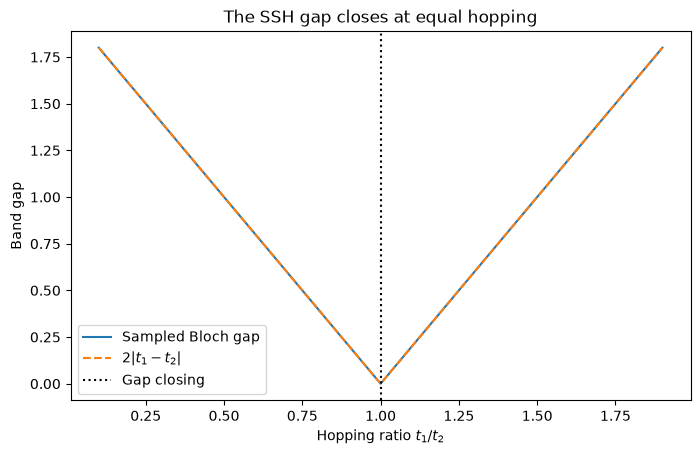

In [5]:
t2_fixed = 1.0
t1_scan = np.linspace(0.1, 1.9, 181)
numerical_gaps = []
for value in t1_scan:
    bands = np.array([np.linalg.eigvalsh(ssh_bloch_hamiltonian(k, value, t2_fixed)) for k in k_dense])
    numerical_gaps.append(np.min(bands[:, 1] - bands[:, 0]))
numerical_gaps = np.array(numerical_gaps)
exact_gaps = 2.0 * np.abs(t1_scan - t2_fixed)
assert_allclose(numerical_gaps, exact_gaps, atol=ATOL, rtol=0.0)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(t1_scan / t2_fixed, numerical_gaps, label="Sampled Bloch gap")
ax.plot(t1_scan / t2_fixed, exact_gaps, "--", label="$2|t_1-t_2|$")
ax.axvline(1.0, color="black", linestyle=":", label="Gap closing")
ax.set_xlabel("Hopping ratio $t_1/t_2$")
ax.set_ylabel("Band gap")
ax.set_title("The SSH gap closes at equal hopping")
ax.legend()
plt.show()


### Interpretation

The numerical and exact gaps agree across the scan. The gap closes only at $t_1/t_2=1$ for this positive-hopping model. This closing is the point at which the winding classification can change continuously; notebook 2 makes that statement visible.


## Summary

The SSH Hamiltonian is a transparent model of alternating hopping on a bipartite chain. Its periodic form produces two symmetric Bloch bands. Unequal hoppings open a gap, and equal hoppings close it at $k=\pi$. Next we use chiral symmetry and the Bloch $d$-vector to distinguish the two gapped regimes under this cell convention.
